# Bilaterality of inverse-Gramian modes vs control cost

## Uses the same data files as in Fig 4

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.stats import spearmanr, pearsonr

DATA_DIR = "HCP_Schaefer400_structural_conn_matrices"
AFF_XLSX = "Schaefer400_networks_affiliations.xlsx"
T = 1.0
P = 2  

aff = pd.read_excel(AFF_XLSX)              
networks = aff["Yeo_7_Networks_ID"].unique().tolist()
print(f"Found {len(networks)} networks: {networks}")

subject_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
print(f"Found {len(subject_files)} subject connectomes")

ImportError: Missing optional dependency 'openpyxl'.  Use pip or conda to install openpyxl.

In [2]:
def bilaterality(V, is_left, p=2):
    L, R = is_left, ~is_left
    EL = (np.abs(V[L, :]) ** p).sum(0)
    ER = (np.abs(V[R, :]) ** p).sum(0)
    LI = (EL - ER) / (EL + ER)
    return 1.0 - np.abs(LI)

def inverse_gramian_modes(A, T=1.0):
    lam, V = eigh(A)  # A symmetric
    W_lam = np.where(np.abs(lam) > 1e-12, (np.exp(2 * lam * T) - 1) / (2 * lam), T)
    W_inv = 1.0 / np.abs(W_lam)
    return W_inv, V

In [3]:
def pool_all_subjects(subject_files, aff, networks, T=1.0, P=1):

    pooled = {net: {'cost': [], 'B': [], 'subject': []} for net in networks}

    for path in subject_files:
        subj_id = os.path.basename(path).split('_')[0]
        C = np.loadtxt(path, delimiter=",")

        if C.shape[0] != len(aff):
            print(f"  [skip] {subj_id}: matrix size {C.shape[0]} != affiliation length {len(aff)}")
            continue

        for net in networks:
            idx = np.where((aff["Yeo_7_Networks_ID"] == net).values)[0]
            A = C[np.ix_(idx, idx)].astype(float)
            names = aff.loc[idx, "Atlas_ROI_Name"].values
            is_left = np.array(["_LH_" in n for n in names])

            W_inv, V = inverse_gramian_modes(A, T=T)
            B = bilaterality(V, is_left, p=P)

            pooled[net]['cost'].append(W_inv)
            pooled[net]['B'].append(B)
            pooled[net]['subject'].append(np.full(len(W_inv), subj_id))

    for net in networks:
        pooled[net]['cost'] = np.concatenate(pooled[net]['cost'])
        pooled[net]['B'] = np.concatenate(pooled[net]['B'])
        pooled[net]['subject'] = np.concatenate(pooled[net]['subject'])

    return pooled

pooled_results = pool_all_subjects(subject_files, aff, networks, T=T, P=P)
for net in networks:
    print(f"{net}: {len(pooled_results[net]['cost'])} pooled modes across {len(subject_files)} subjects")

Visual: 6100 pooled modes across 100 subjects
Somatomotor: 7700 pooled modes across 100 subjects
Dorsal Attention: 4600 pooled modes across 100 subjects
Ventral Attention: 4700 pooled modes across 100 subjects
Limbic: 2600 pooled modes across 100 subjects
Frontoparietal: 5200 pooled modes across 100 subjects
Default Mode: 9100 pooled modes across 100 subjects


In [5]:
def plot_cost_vs_bilaterality(network_name, pooled_results, log_x=False):
    cost = pooled_results[network_name]['cost']
    B    = pooled_results[network_name]['B']

    rho, pval_s = spearmanr(cost, B)
    r,   pval_p = pearsonr(np.log10(cost) if log_x else cost, B)

    x_fit = np.log10(cost) if log_x else cost
    slope, intercept = np.polyfit(x_fit, B, 1)
    x_line = np.linspace(x_fit.min(), x_fit.max(), 200)
    y_line = slope * x_line + intercept

    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.scatter(cost, B, s=12, c="#4878CF", alpha=0.35, edgecolor="none", zorder=2)
    ax.plot(10**x_line if log_x else x_line, y_line, color="#d62728", lw=2, zorder=3,
            label=f"linear fit (Pearson $r={r:+.2f}$)")

    if log_x:
        ax.set_xscale("log")
    ax.set_xlabel(r"Inverse-Gramian eigenvalue $W^{-1}$ (control cost)")
    ax.set_ylabel(r"Bilaterality $B = 1-|\mathrm{LI}|$")
    ax.set_title(f"{network_name}\nSpearman $\\rho={rho:+.2f}$ ($p={pval_s:.1e}$),  "
                 f"Pearson $r={r:+.2f}$ ($p={pval_p:.1e}$),  n={len(cost)}")
    ax.set_ylim(-0.03, 1.03)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    return fig, ax, dict(rho=rho, pval_spearman=pval_s, r=r, pval_pearson=pval_p, n=len(cost))

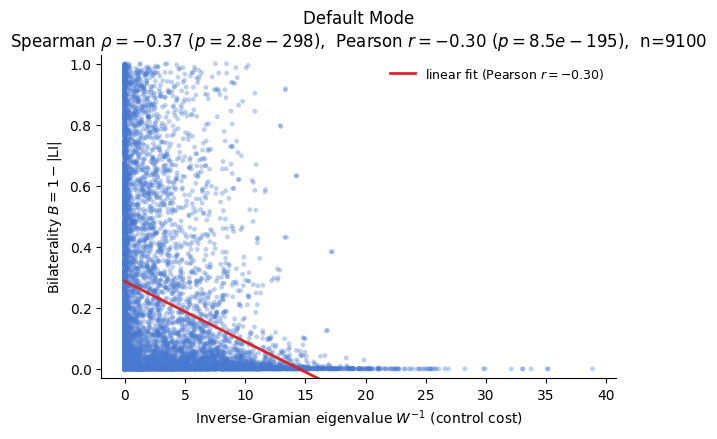

In [6]:
fig, ax, stats = plot_cost_vs_bilaterality("Default Mode", pooled_results)
fig.savefig("results/bilaterality_vs_cost_DefaultMode.png", dpi=200, bbox_inches="tight")
plt.show()

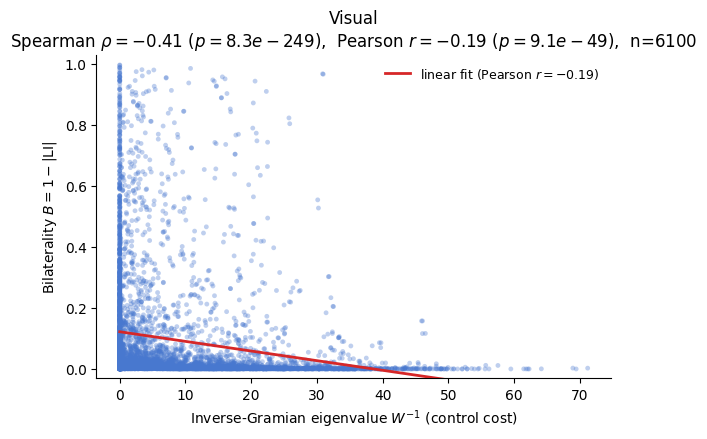

In [7]:
fig, ax, stats = plot_cost_vs_bilaterality("Visual", pooled_results)
fig.savefig("results/bilaterality_vs_cost_Visual.png", dpi=200, bbox_inches="tight")
plt.show()

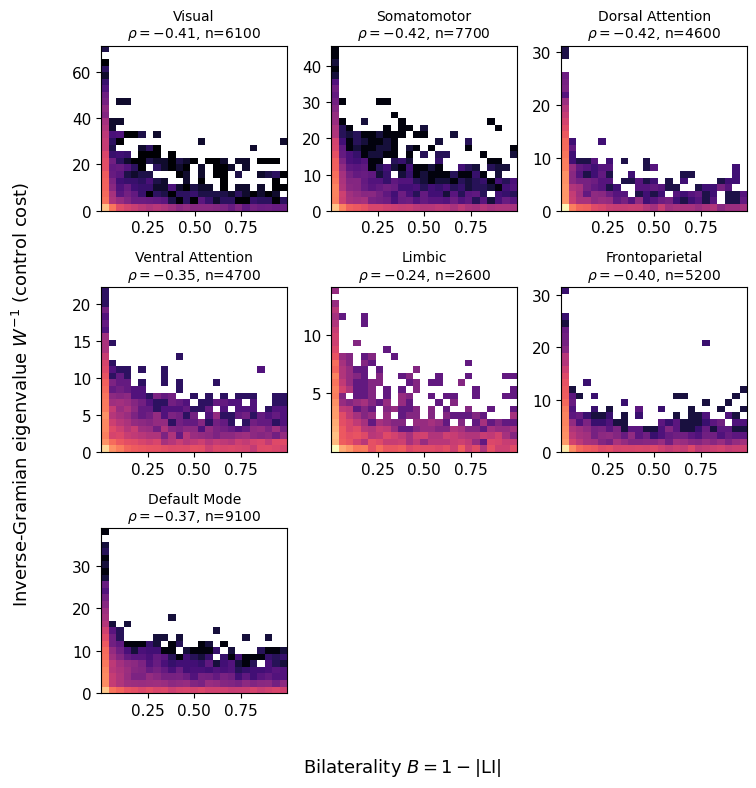

In [9]:
from matplotlib.colors import LogNorm

def compute_density_hist_swapped(network_name, pooled_results, bins=40):
    cost = pooled_results[network_name]['cost']
    B    = pooled_results[network_name]['B']
    rho, pval_s = spearmanr(cost, B)
    H, xedges, yedges = np.histogram2d(B, cost, bins=bins, density=True)
    return H, xedges, yedges, rho, len(cost)

def plot_cost_vs_bilaterality_density_on_ax(ax, network_name, H, xedges, yedges, rho, n, cmap, norm,
                                              tick_labelsize=12):
    H_masked = np.ma.masked_where(H == 0, H)
    pcm = ax.pcolormesh(xedges, yedges, H_masked.T, cmap=cmap, norm=norm, shading="auto")
    ax.set_title(f"{network_name}\n" + r"$\rho$" + f"$={rho:+.2f}$, n={n}", fontsize=10)
    ax.tick_params(axis='both', labelsize=tick_labelsize)
    return pcm

networks_ordered = ["Visual", "Somatomotor", "Dorsal Attention", "Ventral Attention",
                     "Limbic", "Frontoparietal", "Default Mode"]

hists = {}
global_min, global_max = np.inf, -np.inf
for network_name in networks_ordered:
    H, xedges, yedges, rho, n = compute_density_hist_swapped(network_name, pooled_results, bins=25)
    hists[network_name] = (H, xedges, yedges, rho, n)
    nonzero = H[H > 0]
    if nonzero.size:
        global_min = min(global_min, nonzero.min())
        global_max = max(global_max, nonzero.max())

cmap = plt.cm.magma.copy()
cmap.set_bad(color="white")
shared_norm = LogNorm(vmin=global_min, vmax=global_max)

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
axes_flat = axes.flatten()

for ax, network_name in zip(axes_flat, networks_ordered):
    H, xedges, yedges, rho, n = hists[network_name]
    pcm = plot_cost_vs_bilaterality_density_on_ax(ax, network_name, H, xedges, yedges, rho, n,
                                                     cmap, shared_norm, tick_labelsize=11)

axes_flat[7].axis("off")   
axes_flat[8].axis("off") 

fig.supxlabel(r"Bilaterality $B = 1-|\mathrm{LI}|$", fontsize=13, y=0.02)
fig.supylabel(r"Inverse-Gramian eigenvalue $W^{-1}$ (control cost)", fontsize=13, x=0.01)
fig.tight_layout(rect=[0.02, 0.03, 0.95, 1])

fig.savefig("results/bilaterality_density_hist_all_networks.pdf", dpi=200, bbox_inches="tight")
plt.show()